# Dominant colors extraction

The next step neede for creating an authentic cat avatar is to identify pet's color theme. 

## Setup

In [29]:
import os
from transformers import pipeline
from PIL import Image
import io
import json
import requests

import cv2
import numpy as np
import matplotlib.pyplot as pltQ

from sklearn.cluster import KMeans

## Extracting colors from image.

First thing that has to be done is to extract the cat object from an image, so that the background and other stuff does not bias the extracted colors. 

In [30]:
api_key= os.getenv('CAT_API_KEY')
x = requests.get(f'https://api.thecatapi.com/v1/images/search?breed_ids=abys&api_key={api_key}')

data = x.json()

url = data[0]["url"]
print(url)

https://cdn2.thecatapi.com/images/KWdLHmOqc.jpg


After we have got a random image of a cat, we have to cut everyhting except the cat. There are a couple of options for this purpose:
- `rembg` python package (built on top of U2Net - deep-learning-based semantic segmentation), which allows simple background removal from any image. It however cannot be utilized due to incompatible python versions (requires 3.9, current is 3.14).

- Another option was to use `briaai/RMBG-1.4` model via `transformers`, but it has performed poorly, returning a dimmed image.

- A more advanced method which has been tried, is to use SAM 2 from meta (`facebook/sam2.1-hiera-tiny`), but the problem with it has been that the model does not recognize an object, and segments whatever is in the centre of an image.

- The taken approach is to use a **YOLO** model (`yolo11s-seg`), trained to detect objects specifically. 

In [31]:
# built a script which segments a cat from the rest of the image, and makes everything outide the cat's object transparent
from segmentation.remove_background import remove_background as _remove_bg

def remove_background(image_bytes: bytes) -> str:
    image = Image.open(io.BytesIO(image_bytes))
    result = _remove_bg(image)
    return result

In [32]:
response = requests.get(url).content
cat_no_bg = remove_background(response)

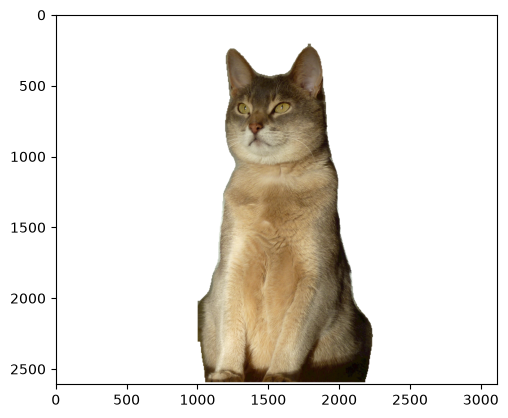

In [33]:
img = np.asarray(cat_no_bg)
imgplot = pltQ.imshow(img)

Now that the cat is extracted from the image, we can adopt the algorithm for dominant colors extraction. To achieve this, an easy way is to use K-Means clustering, somehow. Thanks to gentleman NitinCVOrbit, for showcasing his approach of impementing this feature (https://github.com/NitinCVOrbit/Extract-Dominant-Colors-from-Any-Image-using-K-Means-Python-OpenCV). The idea is to split pixels into n segments, based on RGB values. This way not only we get the colors, but also "how much of each color is in the cat".

In [34]:
def centroid_histogram(clustering):
    labels = clustering.labels_

    print("Different Labels ==> ", np.unique(labels))

    num_clusters = len(np.unique(labels))

    bins = np.arange(0, num_clusters + 1)

    hist, _ = np.histogram(labels, bins=bins)
    print('Hist Before Float ==> ',hist)

    hist = hist.astype("float")    
    print('Hist After Float ==> ',hist)

    hist /= hist.sum()
    print('Hist Percentage Clc ==> ',hist)

    return hist

In [35]:
def plot_colors(hist, centroids, bar_height=100, bar_width=500):

    bar = np.zeros((bar_height, bar_width, 3), dtype="uint8")

    start_x = 0

    for percentage, color in zip(hist, centroids):

        end_x = start_x + int(percentage * bar_width)
        print(f'End_x {color} ==> ',end_x)

        cv2.rectangle(
            bar,
            (int(start_x), 0),
            (int(end_x), bar_height),
            color.astype("uint8").tolist(),
            -1
        )

        start_x = end_x

    return bar

Clusters Labels ==>  [1 1 1 ... 3 3 3]
Length Clusters Labels ==>  2026210
Clusters Centers ==>  [[     213.52      194.38       155.6]
 [     99.622      80.501      53.239]
 [     183.61      157.47      115.28]
 [     47.627      31.824      14.904]
 [     145.56      121.02      84.677]]
Different Labels ==>  [0 1 2 3 4]
Hist Before Float ==>  [360236 362435 547976 302050 453513]
Hist After Float ==>  [ 3.6024e+05  3.6244e+05  5.4798e+05  3.0205e+05  4.5351e+05]
Hist Percentage Clc ==>  [    0.17779     0.17887     0.27044     0.14907     0.22382]
End_x [     213.52      194.38       155.6] ==>  88
End_x [     99.622      80.501      53.239] ==>  177
End_x [     183.61      157.47      115.28] ==>  312
End_x [     47.627      31.824      14.904] ==>  386
End_x [     145.56      121.02      84.677] ==>  497


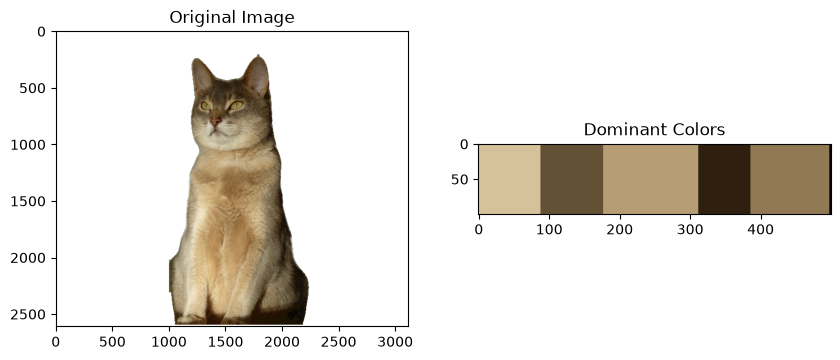

In [ ]:
def extract_dominant_colors(image):
    mask = img[:, :, 3] > 0
    pixels = img[mask][:, :3]

    clt = KMeans(n_clusters=5, random_state=42)
    clt.fit(pixels)

    print('Clusters Labels ==> ', clt.labels_)
    print('Length Clusters Labels ==> ', len(clt.labels_))

    print('Clusters Centers ==> ', clt.cluster_centers_)

    hist = centroid_histogram(clt)

    bar = plot_colors(hist, clt.cluster_centers_)

    fig, ax = pltQ.subplots(1, 2, figsize=(10, 10))
    ax = ax.ravel()

    ax[0].imshow(image)
    ax[0].set_title("Original Image")

    ax[1].imshow(bar)
    ax[1].set_title("Dominant Colors")

    pltQ.show()

extract_dominant_colors(img)